## Proses Import Library

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import matplotlib.pyplot as plt
import seaborn as sns

## Proses Memuat Dataset Hasil Feature Engineering

In [2]:
data_model = pd.read_csv(
    r"D:\Dokumen Bootcamp Dibimbing 2025\[WAJIB] Final Take Home Test\Take Home Test_Raihan Azhar Rafi\Data\data_model_final.csv"
)

data_model.head()

,User_id,target_pembelian,jumlah_search,jumlah_lihat_produk,jumlah_baca_review,jumlah_keranjang,jumlah_checkout
0,51443820326,0,1,0,0,0,0
1,51448162784,1,2,1,2,2,2
2,51455512201,1,2,2,2,1,1
3,51462598385,1,4,4,1,2,2
4,51463622150,1,4,2,1,2,2


## Proses Memisahkan Fitur dan Target

In [3]:
fitur = data_model[
    [
        "jumlah_search",
        "jumlah_lihat_produk",
        "jumlah_baca_review",
        "jumlah_keranjang",
        "jumlah_checkout"
    ]
]

target = data_model["target_pembelian"]

print("Ukuran Data Fitur:", fitur.shape)
print("Ukuran Data Target:", target.shape)

fitur.head()

Ukuran Data Fitur: (401, 5)
Ukuran Data Target: (401,)


,jumlah_search,jumlah_lihat_produk,jumlah_baca_review,jumlah_keranjang,jumlah_checkout
0,1,0,0,0,0
1,2,1,2,2,2
2,2,2,2,1,1
3,4,4,1,2,2
4,4,2,1,2,2


## Proses Train Test Split

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    fitur,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

print("Data Training :", x_train.shape)
print("Data Testing :", x_test.shape)

Data Training : (320, 5)
Data Testing : (81, 5)


## Insight Proses Train Test Split

1. Sebanyak 320 data pelanggan digunakan untuk pelatihan model dan 81 data pelanggan digunakan untuk evaluasi model.
2. Setiap data pelanggan memiliki 5 fitur perilaku yang akan digunakan untuk memprediksi target pembelian.
3. Pembagian data 80:20 untuk menjaga keseimbangan antara kebutuhan pelatihan model dan kebutuhan evaluasi model.
4. (stratify = target) membantu menjaga distribusi target pembelian tetap konsisten pada data training dan testing.
5. Dataset telah siap untuk masuk ke tahap Feature Scaling dan pelatihan model Deep Learning ANN.

## Proses Feature Scaling

In [5]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(
    x_train
)

x_test_scaled = scaler.transform(
    x_test
)

print(x_train_scaled.shape)
print(x_test_scaled.shape)

pd.DataFrame(
    x_train_scaled,
    columns=fitur.columns
).head()

(320, 5)
(81, 5)


,jumlah_search,jumlah_lihat_produk,jumlah_baca_review,jumlah_keranjang,jumlah_checkout
0,-0.750806,-0.795491,0.176866,0.462267,0.752662
1,0.173263,0.301738,0.176866,-1.062736,-0.781426
2,0.173263,0.301738,0.176866,-1.062736,-0.781426
3,-0.750806,0.301738,0.176866,-1.062736,-0.781426
4,-0.750806,0.301738,0.176866,-1.062736,-0.781426


In [6]:
pd.DataFrame(
    x_train_scaled,
    columns=fitur.columns
).describe()

,jumlah_search,jumlah_lihat_produk,jumlah_baca_review,jumlah_keranjang,jumlah_checkout
count,3.200000e+02,3.200000e+02,3.200000e+02,3.200000e+02,3.200000e+02
mean,-3.885781e-17,5.273559e-17,4.440892e-17,-3.330669e-17,-2.220446e-17
std,1.001566e+00,1.001566e+00,1.001566e+00,1.001566e+00,1.001566e+00
min,-7.508057e-01,-7.954914e-01,-1.053503e+00,-1.062736e+00,-7.814264e-01
25%,-7.508057e-01,-7.954914e-01,-1.053503e+00,-1.062736e+00,-7.814264e-01
50%,1.732628e-01,3.017381e-01,1.768655e-01,4.622665e-01,-7.814264e-01
75%,1.732628e-01,3.017381e-01,1.768655e-01,4.622665e-01,7.526622e-01
max,4.793605e+00,5.787886e+00,6.328710e+00,3.512273e+00,3.820839e+00


## Insight Proses Feature Scaling

1. Tujuan Proses Feature Scaling untuk menormalisasi data dengan cara menyamakan skala seluruh fitur sebelum digunakan pada model Deep Learning.
2. Pada projek ini digunakan metode StandardScaler, cara kerjanya mengubah data menjadi skala standar berdasarkan rata-rata (mean) dan standar deviasi (standard deviation) terhadap masing-masing fitur.
3. StandardScaler berhasil mengubah seluruh fitur sehingga memiliki rata-rata (mean) mendekati 0 dan standar deviasi (std) mendekati 1. Pembuktian untuk hasil mean mendekati nilai 0 lewat proses pembulatan pada mean di fitur jumlah_search, dengan cara:
= round(-3.8857805861880476e-17, 10) hasilnya = -0.0 
4. Karakteristik perilaku pelanggan tetap dipertahankan meskipun skala data telah diubah. Dibuktikan masih terdapat beberapa pelanggan dengan tingkat aktivitas yang jauh di atas rata-rata populasi, yang terlihat dari nilai maksimum yang relatif tinggi setelah proses scaling.
5. Dataset hasil scaling siap digunakan untuk membangun model Artificial Neural Network (ANN).

## Proses Membangun Model Artificial Neural Network (ANN)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input

model_ann = Sequential()

model_ann.add(
    Input(shape=(5,))
)

model_ann.add(
    Dense(
        16,
        activation="relu"
    )
)

model_ann.add(
    Dense(
        8,
        activation="relu"
    )
)

model_ann.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

model_ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

## Insight Proses Membangun Model Artificial Neural Network (ANN)

1. Pada tahap ini dibangun model Artificial Neural Network (ANN) yang bertujuan untuk mempelajari pola hubungan antara aktivitas pelanggan dan keputusan pembelian.
2. Model ANN menggunakan 5 fitur input yang digunakan model untuk memprediksi target pembelian pelanggan, detailnya seperti ini:
- jumlah_search
- jumlah_lihat_produk
- jumlah_baca_review
- jumlah_keranjang
- jumlah_checkout
3. Arsitektur ANN terdiri dari:
- Input Layer (5 fitur)
- Hidden Layer 1 (16 neuron)
- Hidden Layer 2 (8 neuron)
- Output Layer (1 neuron)
Struktur tersebut memungkinkan model mempelajari pola perilaku pelanggan secara bertahap dari hubungan yang sederhana hingga hubungan yang lebih kompleks.
4. Hidden Layer pertama menggunakan 16 neuron yang berfungsi menangkap pola awal dari aktivitas pelanggan, contohnya hubungan antara pencarian produk, aktivitas keranjang, dan checkout terhadap pembelian.
5. Hidden Layer kedua menggunakan 8 neuron yang berfungsi memperdalam proses pembelajaran dengan mengkombinasikan pola-pola yang telah dipelajari pada layer sebelumnya.
6. Output Layer terdiri dari 1 neuron dengan fungsi aktivasi sigmoid yang menghasilkan nilai probabilitas antara 0 dan 1, interpretasinya seperti ini:
- mendekati 0 = tidak membeli
- mendekati 1 = membeli
7. Model memiliki 241 parameter yang dapat dipelajari, parameter nya berupa bobot (weights) dan bias yang akan disesuaikan selama proses pelatihan agar model dapat menghasilkan prediksi yang akurat dan juga seluruh neuron akan ikut diperbarui selama proses training untuk mempelajari pola perilaku pelanggan.
8. Arsitektur yang digunakan cukup sederhana karena parameter yang digunakan cukup sedikit yang terdiri dari 5 fitur utama. Kondisi tersebut membantu mengurangi risiko overfitting.


## Proses Kompilasi Model Artificial Neural Network (ANN)

In [8]:
model_ann.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## Insight Proses Kompilasi Model Artificial Neural Network (ANN)

1. Proses kompilasi dilakukan untuk menentukan konfigurasi pembelajaran yang akan digunakan selama pelatihan model Artificial Neural Network (ANN).
2. Model menggunakan optimizer Adam yang berfungsi untuk memperbarui bobot jaringan secara otomatis agar nilai error dapat di minimalisir setiap iterasi pelatihan.
3. Fungsi loss yang digunakan adalah Binary Crossentropy karena permasalahan yang dihadapi merupakan klasifikasi biner, yaitu memprediksi pelanggan membeli (1) dan tidak membeli (0).
4. Metrik evaluasi yang digunakan adalah Accuracy untuk mengukur persentase prediksi yang berhasil diklasifikasikan dengan benar oleh model.

## Proses Pelatihan Model Artificial Neural Network (ANN)

In [9]:
riwayat_model = model_ann.fit(
    x_train_scaled,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6328 - loss: 0.6476 - val_accuracy: 0.7500 - val_loss: 0.6060
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7539 - loss: 0.5892 - val_accuracy: 0.9062 - val_loss: 0.5564
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9336 - loss: 0.5299 - val_accuracy: 0.9688 - val_loss: 0.5023
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9688 - loss: 0.4701 - val_accuracy: 1.0000 - val_loss: 0.4524
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9805 - loss: 0.4191 - val_accuracy: 1.0000 - val_loss: 0.4072
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9805 - loss: 0.3744 - val_accuracy: 1.0000 - val_loss: 0.3631
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9805 - loss: 0.3305 - val_accuracy: 1.0000 - val_loss: 0.3188
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9805 - loss: 0.2895 - val_accuracy: 1.0000 - v

## Insight Proses Pelatihan Model Artificial Neural Network (ANN)

1. Model berhasil dilatih sebanyak 50 epoch.
2. Accuracy meningkat dari epoch awal hingga epoch akhir dan juga Loss menurun dari epoch awal ke epoch akhir.
3. Hasilnya model menunjukkan proses training yang baik.

## Proses Visualisasi Accuracy Training

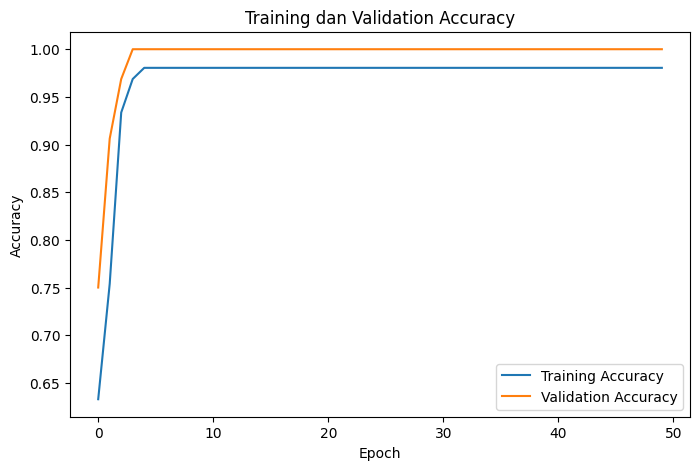

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    riwayat_model.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    riwayat_model.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training dan Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [11]:
print(
    "Training Accuracy Terakhir:",
    riwayat_model.history["accuracy"][-1]
)

print(
    "Validation Accuracy Terakhir:",
    riwayat_model.history["val_accuracy"][-1]
)

Training Accuracy Terakhir: 0.98046875
Validation Accuracy Terakhir: 1.0


## Insight Proses Visualisasi Accuracy Training

1. Pada awal training, Accuracy model masih berada di kisaran 66–69%, kemudian meningkat signifikan sekitar 98% pada data training dan 100% pada data validation. Peningkatan tersebut menunjukkan bahwa fitur-fitur hasil Feature Engineering memiliki hubungan yang kuat terhadap target pembelian pelanggan.
2. Di epoch ke-12, Validation Accuracy mencapai nilai sekitar 100% dan kemudian cenderung stabil hingga akhir training. Hal tersebut menunjukkan bahwa model mampu mengklasifikasikan seluruh data validasi dengan benar sejak pertengahan proses training.
3. Ada temuan yang cukup unik dimana Training Accuracy berhenti di sekitar 98,05%, sedangkan Validation Accuracy mencapai 100%, biasanya Training Accuracy sedikit lebih tinggi daripada Validation Accuracy. Oleh karena itu, hasil ini perlu di evaluasi pada data testing agar dapat dipastikan bahwa performa model bisa terhindar dari indikasi overfitting.

## Proses Visualisasi Loss Training

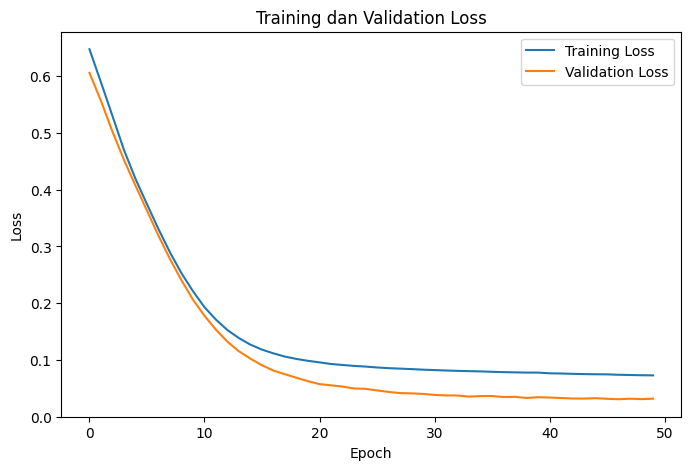

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    riwayat_model.history["loss"],
    label="Training Loss"
)

plt.plot(
    riwayat_model.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training dan Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [13]:
print(
    "Training Loss Terakhir:",
    riwayat_model.history["loss"][-1]
)

print(
    "Validation Loss Terakhir:",
    riwayat_model.history["val_loss"][-1]
)

Training Loss Terakhir: 0.07265699654817581
Validation Loss Terakhir: 0.031651854515075684


## Insight Proses Visualisasi Loss Training

1. Di tahap Loss ini merupakan ukuran kesalahan prediksi model. Tujuan utama nya adalah untuk meminimalkan nilai loss pada proses training.
2. Pada grafik tersebut menunjukkan bahwa Training Loss turun secara signifikan dari sekitar 0,65 pada awal training menjadi 0,0748 pada epoch terakhir. Penurunan tersebut menunjukkan bahwa model semakin mampu mempelajari hubungan antara perilaku pelanggan dan keputusan pembelian.
3. Pada Validation Loss juga mengalami penurunan dari sekitar 0,61 menjadi 0,0288. Hal tersebut menunjukkan bahwa kemampuan model semakin baik dalam proses prediksi seiring bertambahnya epoch.
4. Tidak ditemukan indikasi overfitting karena tidak terlihat adanya kenaikan Validation Loss pada akhir proses training, biasanya tanda-tanda overfitting itu Training Loss nya terus turun tetapi Validation Loss mulai meningkat.
5. Jarak antara training loss dan validation loss relatif kecil dan bergerak dengan pola yang sama. Kondisi tersebut menunjukkan bahwa model memiliki kemampuan generalisasi yang baik dan tidak hanya menghafal data training.
6. Model Artificial Neural Network (ANN) siap dievaluasi menggunakan data testing untuk mengukur performa akhir model.

## Proses Prediksi Data Testing

In [14]:
prediksi_probabilitas = model_ann.predict(
    x_test_scaled
)

prediksi_ann = (
    prediksi_probabilitas > 0.5
).astype(int)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


## Proses Evaluasi Model Artificial Neural Network (ANN)

In [15]:
akurasi_ann = accuracy_score(
    y_test,
    prediksi_ann
)

print(
    "Akurasi ANN:",
    akurasi_ann
)

print(
    classification_report(
        y_test,
        prediksi_ann
    )
)

Akurasi ANN: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       1.00      1.00      1.00        34

    accuracy                           1.00        81
   macro avg       1.00      1.00      1.00        81
weighted avg       1.00      1.00      1.00        81



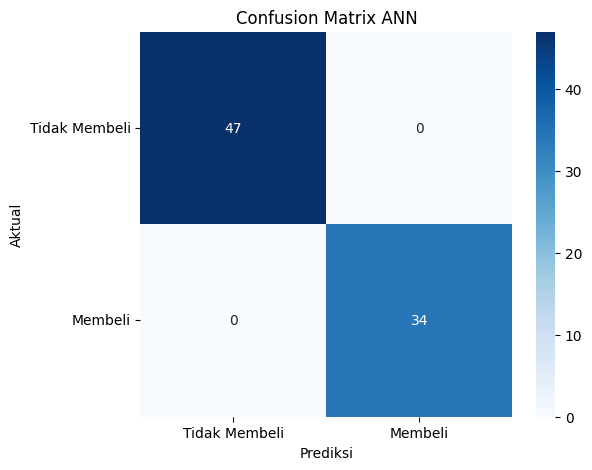

In [16]:
cm_ann = confusion_matrix(
    y_test,
    prediksi_ann
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_ann,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix ANN")

plt.xlabel("Prediksi")
plt.ylabel("Aktual")

plt.xticks(
    [0.5,1.5],
    ["Tidak Membeli","Membeli"]
)

plt.yticks(
    [0.5,1.5],
    ["Tidak Membeli","Membeli"],
    rotation=0
)

plt.show()

## Insight Proses Evaluasi Model Artificial Neural Network (ANN)

1. Model ANN berhasil mencapai akurasi 100% pada data testing. Precision, Recall, dan F1-Score seluruh kelas mencapai nilai sempurna sebesar 1.00. Model mampu membedakan pelanggan yang membeli dan tidak membeli tanpa kesalahan pada proses klasifikasi.
2. Performa tinggi model kemungkinan dipengaruhi oleh kekuatan fitur perilaku pelanggan, terutama di aktivitas checkout dan keranjang yang memiliki hubungan langsung dengan proses pembelian.

## Proses Perbandingan Model Random Forest dan ANN

In [17]:
hasil_model = pd.DataFrame({
    "Model":[
        "Random Forest",
        "ANN"
    ],
    "Accuracy":[
        1.0,
        akurasi_ann
    ]
})

hasil_model

,Model,Accuracy
0,Random Forest,1.0
1,ANN,1.0


## Proses Simulasi Prediksi Pelanggan Baru Menggunakan ANN

In [18]:
pelanggan_baru = pd.DataFrame({
    "jumlah_search":[4],
    "jumlah_lihat_produk":[3],
    "jumlah_baca_review":[2],
    "jumlah_keranjang":[2],
    "jumlah_checkout":[1]
})

pelanggan_baru_scaled = scaler.transform(
    pelanggan_baru
)

probabilitas_ann = model_ann.predict(
    pelanggan_baru_scaled
)

print(
    "Probabilitas Membeli:",
    probabilitas_ann[0][0]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Probabilitas Membeli: 0.9995613


## Proses Menyimpan Model Proses Deep Learning Model Artificial Neural Network (ANN)

In [19]:
model_ann.save(
    "../Model/model_ann.keras"
)